In [13]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import sklearn as sl

from sklearn.datasets import make_circles, make_moons

## 1. Generate Toy Datasets

In [14]:
# generate moon dataset
coord_moon, label_moon = make_moons(500, noise=0.025)

# generate circle dataset 
coord_circle, label_circle = make_circles(500, noise=0.025)

# dtype of dataset
print(type(coord_circle))

# dimension of data
print(coord_circle.shape)
print(label_circle.shape)

print(coord_circle[0])

<class 'numpy.ndarray'>
(500, 2)
(500,)
[-0.40407947 -0.69550246]


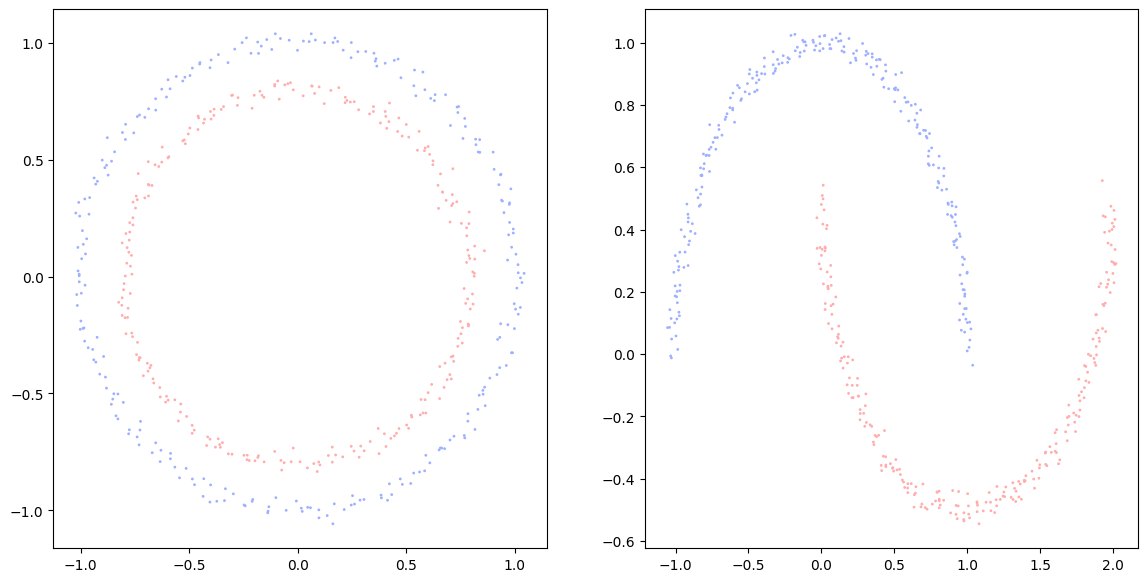

In [15]:
# plot datasets
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# plot circle data
ax[0].scatter(coord_circle[... , 0], coord_circle[... , 1], s=1, c=label_circle, cmap="berlin")

# plot moon data
ax[1].scatter(coord_moon[... , 0], coord_moon[... , 1], s=1, c=label_moon, cmap="berlin")

In [16]:
# Turn circle data into tensor dataset
x_circle_tensor = torch.from_numpy(coord_circle[..., 0]).float()
y_circle_tensor = torch.from_numpy(coord_circle[..., 1]).float()

circle_dataset = TensorDataset(x_circle_tensor, y_circle_tensor)

# Turn moon data into tensor dataset
x_moon_tensor = torch.from_numpy(coord_moon[..., 0]).float()
y_moon_tensor = torch.from_numpy(coord_moon[..., 1]).float()

moon_dataset = TensorDataset(x_moon_tensor, y_moon_tensor)

# Turn Datasets into Dataloader
circle_data = DataLoader(circle_dataset, batch_size=16)
moon_data = DataLoader(moon_dataset, batch_size=16)

## 2. ODE-Solver

### 2.1 Euler Method

In [28]:
# recursive approach but problem with overflow
def euler_step(model, y_n, t_n, step_size):
    step = y_n + step_size * model(y_n, t_n)
    return step

def euler_solver_recursion(model, y_0, t_0, nb_steps, step_size):
    # base case
    if nb_steps == 0:
        return y_next, t_next

    # calculate next step
    y_next = euler_step(model, y_0, t_0, step_size)
    t_next = step_size + t_0

    y_end = euler_solver_recursion(model, y_next, t_next, nb_steps-1, step_size)

    return y_end


In [29]:
# euler ode solver without recursion
def euler_solver(model, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = euler_step(model, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.2 Runge-Kutta method (RK4)

In [31]:
# Runge-Kutta implemenatation (RK4)
def rk4_step(model, y_n, t_n, stepsize):
    # calculate k_n for n in [1, 2, 3, 4] for weighted average of the four increments
    k_1 = model(y_n, t_n)
    k_2 = model(y_n + k_1 * stepsize / 2, t_n + stepsize / 2)
    k_3 = model(y_n + k_2 * stepsize / 2, t_n + stepsize / 2)
    k_4 = model(y_n + stepsize * k_3, t_n + stepsize)

    # calculate step
    step = y_n + stepsize / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return step

def rk4_solver(model, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = rk4_step(model, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.3 Test ODE Solver

In [44]:
# analytical solution
# dy/dt = -y, y(t) = y_0 * exp(-t)
# dy/dt = 2t, y(t) = y_0 + t^2

def model_exp(y, t):
    """dy/dt = -y"""
    return -y

def model_linear(y, t):
    """dy/dt = 2"""
    return 2

In [46]:
# testing euler 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = euler_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = euler_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = euler_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3677), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487]]), 0.9999999999999999)


In [47]:
# testing rk4 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = rk4_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = rk4_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = rk4_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3679), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679]]), 0.9999999999999999)


## 3. Adjoint-based Backpropagation 

In [ ]:
# custom autograd.Function s.t. pytorch does not calculate computational graph for autograd
class AdjointSolver(torch.autograd.Function):

    # forward pass through the vectorfield-model
    @staticmethod
    def forward(ctx, model, y_0, t_0, t_end, nb_steps, solver):
        # calculate stepsize
        step_size = torch.floor((t_end - t_0) / nb_steps)

        # solve initial value problem
        y_end = solver(model, y_0, t_0, nb_steps, step_size)[0]

        # safe variables for backward step
        ctx.model = model
        ctx.save_for_backward(y_end)
        ctx.save_for_backward(y_0)
        ctx.t_0 = t_0
        ctx.t_end = t_end
        ctx.nb_steps = nb_steps
        ctx.solver = solver

        return y_end, t_end 
    
    # backward pass with adjoint vectorfield to get derivative of loss in respect to param of model
    @staticmethod
    def backward(ctx, a_end):
        # import saved variables from forwardpass
        model = ctx.model
        y_end, y_0, = ctx.saved_tensors
        t_0 = ctx.t_0
        t_end = ctx.t_end
        nb_steps = ctx.nb_steps
        solver = ctx.solver

        ### IMPORTANT: NEED TO LOOK AT HOW UNSUPERVISED LEARNING WORKS IN THIS CASE! WHAT IS NEEDED AS OBJECTIVE? HOW IS DISTRIBUTION LEARNT? ###
        ### NEED TO THINK HOW THE CONNECTION BETWEEN N(0,1) AND "NOT KNOWN" DATA DISTRIBUTION IS MADE ###

        
    



## 4. Model Initialization

## 5. Model Training

## 6. Model Evaluation/ Visualization